<a href="https://colab.research.google.com/github/TejasKayarkar03/Pattern-Recognition-Lab/blob/main/PR_CM23045_Pr7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
!pip install easyocr opencv-python lxml -q

In [4]:
!pip install kagglehub -q

import kagglehub

path = kagglehub.dataset_download("andrewmvd/car-plate-detection")

print("Dataset Path:", path)

100%|██████████| 203M/203M [00:01<00:00, 115MB/s]

Extracting files...


Dataset Path: /root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1


In [9]:
import os

for root, dirs, files in os.walk(path):
    for file in files[:5]:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/annotations/Cars34.xml
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/annotations/Cars341.xml
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/annotations/Cars371.xml
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/annotations/Cars243.xml
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/annotations/Cars61.xml
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/images/Cars197.png
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/images/Cars330.png
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/images/Cars173.png
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/images/Cars244.png
/root/.cache/kagglehub/datasets/andrewmvd/car-plate-detection/versions/1/images/Cars94.png


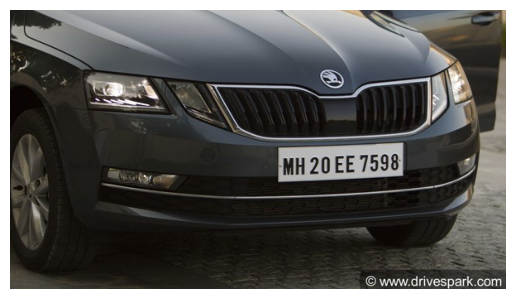

In [105]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os

image_folder = os.path.join(path, "images")
annotation_folder = os.path.join(path, "annotations")

image_name = sorted(os.listdir(image_folder))[15]
xml_name = image_name.replace(".png", ".xml").replace(".jpg", ".xml")

img_path = os.path.join(image_folder, image_name)
xml_path = os.path.join(annotation_folder, xml_name)

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

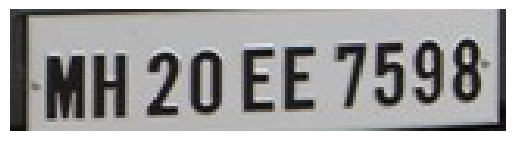

In [106]:
tree = ET.parse(xml_path)
root = tree.getroot()

for obj in root.findall("object"):
    box = obj.find("bndbox")

    xmin = int(box.find("xmin").text)
    ymin = int(box.find("ymin").text)
    xmax = int(box.find("xmax").text)
    ymax = int(box.find("ymax").text)

plate = image[ymin:ymax, xmin:xmax]

plt.imshow(plate)
plt.axis("off")
plt.show()

In [107]:
import easyocr

reader = easyocr.Reader(['en'])

result = reader.readtext(plate)

for r in result:
    print(r[1])

MH 20 EE 7598


In [108]:
plate_text = ""

if len(result) > 0:
    plate_text = result[0][1]

print("Detected Plate:", plate_text)

Detected Plate: MH 20 EE 7598


In [109]:
import re

plate_text = plate_text.upper()

plate_text = re.sub(r'[^A-Z0-9]', '', plate_text)

print(plate_text)

MH20EE7598


In [118]:
pattern = r'^[A-Z]{2}[0-9]{2}[A-Z]{1,2}[0-9]{4}$'

if re.match(pattern, plate_text):
    print("Valid Indian Registration Number")
else:
    print("Invalid Registration Number")

Valid Indian Registration Number


In [116]:
from nltk.tree import Tree

match = re.match(r'^([A-Z]{2})([0-9]{2})([A-Z]{1,2})([0-9]{4})$', plate_text)

if match:

    state, district, series, number = match.groups()

    tree = Tree("Registration", [

        Tree("State", [state]),

        Tree("District", [district]),

        Tree("Series", [series]),

        Tree("VehicleNumber", [number])

    ])

    tree.pretty_print()

    print(tree)

else:

    print("Cannot build parse tree.")

      Registration                     
   ________|____________________        
State   District   Series VehicleNumber
  |        |         |          |       
  MH       20        EE        7598    

(Registration
  (State MH)
  (District 20)
  (Series EE)
  (VehicleNumber 7598))


In [112]:
from nltk import CFG

grammar = CFG.fromstring("""

Registration -> State District Series VehicleNumber

State -> 'MH' | 'DL' | 'KA' | 'TN' | 'RJ' | 'WB'

District -> '01' | '02' | '10' | '12' | '14' | '20' | '31'

Series -> 'A' | 'AB' | 'CD' | 'XY'

VehicleNumber -> '1234' | '5678' | '1111' | '9999'

""")

print(grammar)

Grammar with 22 productions (start state = Registration)
    Registration -> State District Series VehicleNumber
    State -> 'MH'
    State -> 'DL'
    State -> 'KA'
    State -> 'TN'
    State -> 'RJ'
    State -> 'WB'
    District -> '01'
    District -> '02'
    District -> '10'
    District -> '12'
    District -> '14'
    District -> '20'
    District -> '31'
    Series -> 'A'
    Series -> 'AB'
    Series -> 'CD'
    Series -> 'XY'
    VehicleNumber -> '1234'
    VehicleNumber -> '5678'
    VehicleNumber -> '1111'
    VehicleNumber -> '9999'


In [113]:
print("Detected Plate:", plate_text)
print("Length:", len(plate_text))

Detected Plate: MH20EE7598
Length: 10


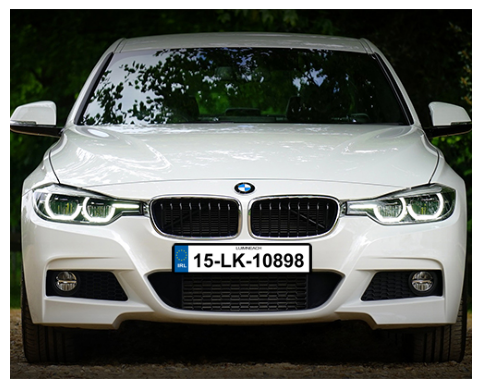

In [114]:
import cv2
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import os

image_folder = os.path.join(path, "images")
annotation_folder = os.path.join(path, "annotations")

image_name = sorted(os.listdir(image_folder))[76]
xml_name = image_name.replace(".png", ".xml").replace(".jpg", ".xml")

img_path = os.path.join(image_folder, image_name)
xml_path = os.path.join(annotation_folder, xml_name)

image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.axis("off")
plt.show()

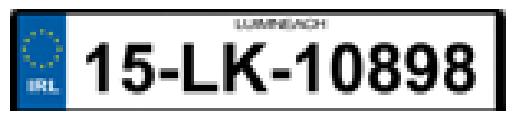

In [115]:
tree = ET.parse(xml_path)
root = tree.getroot()

for obj in root.findall("object"):
    box = obj.find("bndbox")

    xmin = int(box.find("xmin").text)
    ymin = int(box.find("ymin").text)
    xmax = int(box.find("xmax").text)
    ymax = int(box.find("ymax").text)

plate = image[ymin:ymax, xmin:xmax]

plt.imshow(plate)
plt.axis("off")
plt.show()